In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv(r"C:\Users\saith\OneDrive\Desktop\Crop Recomendation System\Crop_recommendation.csv")

In [4]:
df.head(5)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [5]:
df.shape

(2200, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [7]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [8]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [15]:
df.corr(numeric_only=True)

,N,P,K,temperature,humidity,ph,rainfall
N,1.000000,-0.231460,-0.140512,0.026504,0.190688,0.096683,0.059020
P,-0.231460,1.000000,0.736232,-0.127541,-0.118734,-0.138019,-0.063839
K,-0.140512,0.736232,1.000000,-0.160387,0.190859,-0.169503,-0.053461
temperature,0.026504,-0.127541,-0.160387,1.000000,0.205320,-0.017795,-0.030084
humidity,0.190688,-0.118734,0.190859,0.205320,1.000000,-0.008483,0.094423
ph,0.096683,-0.138019,-0.169503,-0.017795,-0.008483,1.000000,-0.109069
rainfall,0.059020,-0.063839,-0.053461,-0.030084,0.094423,-0.109069,1.000000


In [18]:
print(df.duplicated().sum())

0


<Axes: >

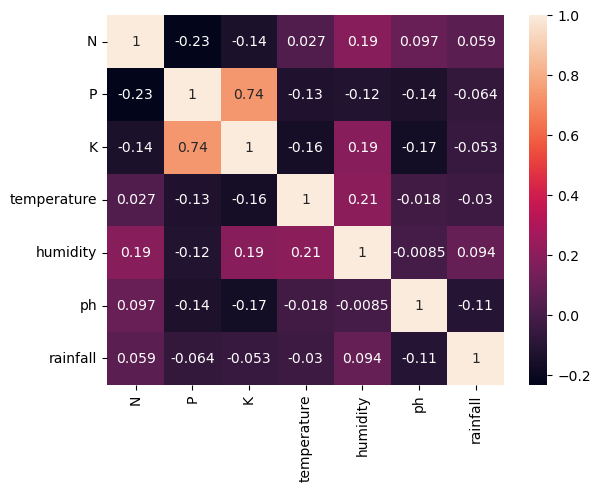

In [23]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

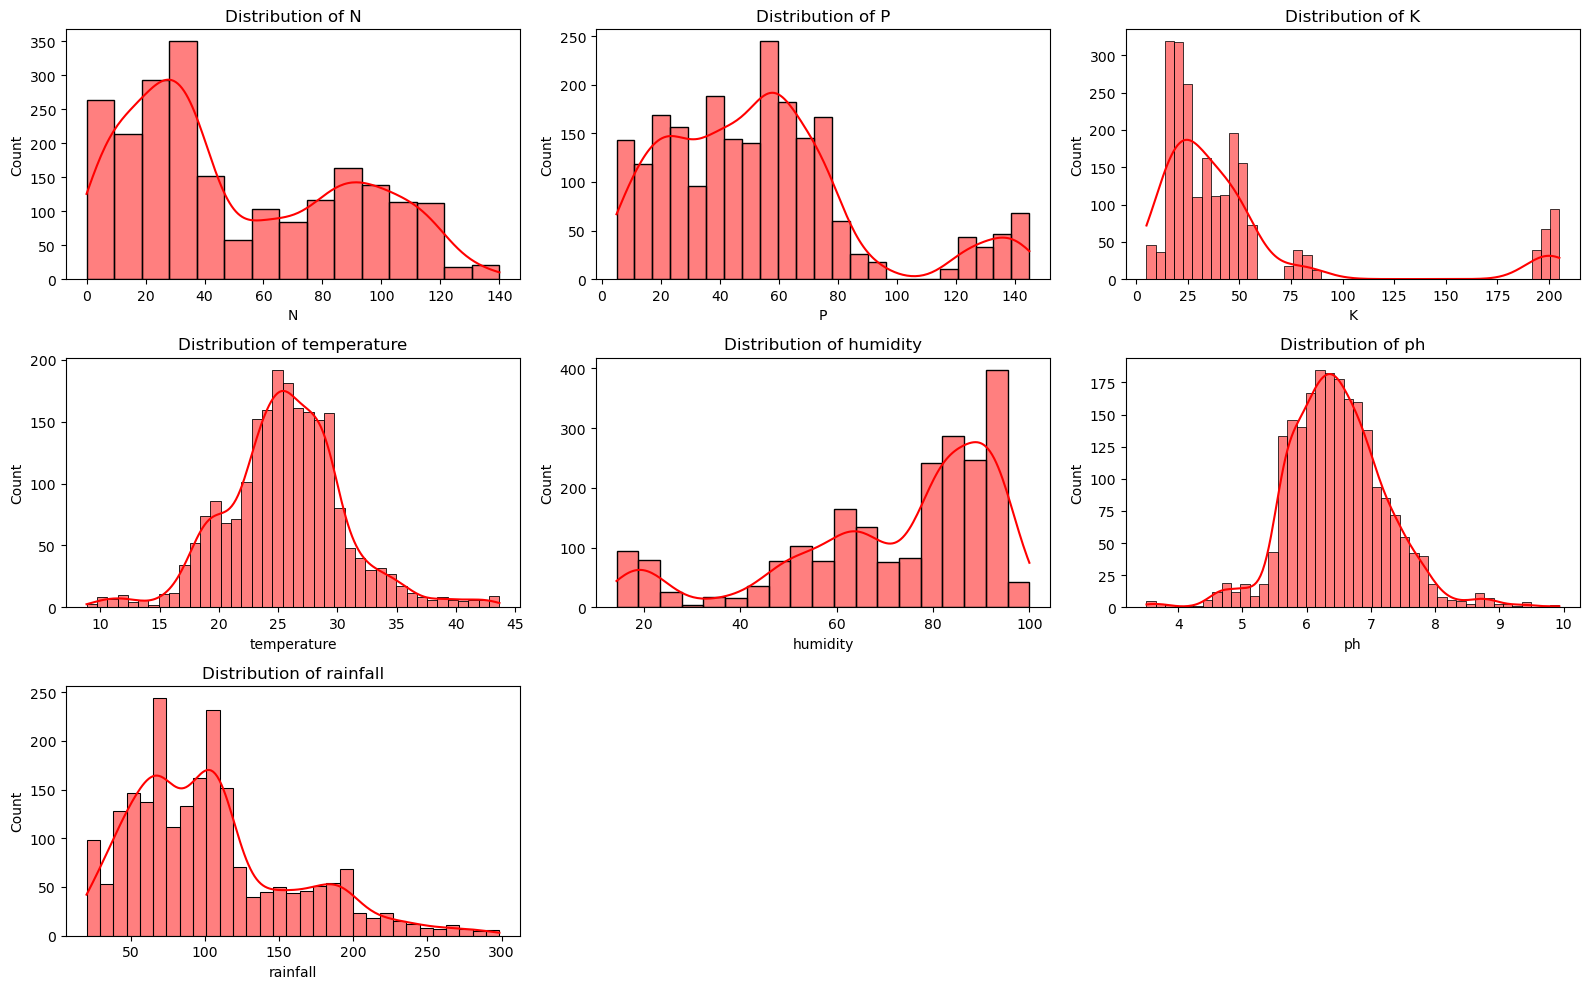

In [37]:
cols = ['N','P','K','temperature','humidity','ph','rainfall']

plt.figure(figsize=(16, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 3, i)   # 3 rows × 3 columns grid
    sns.histplot(df[col], kde=True,color='r')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [41]:
df.label.unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [71]:

X = df.drop("label", axis=1)
y = df["label"]

In [72]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [73]:
# 3. Feature types

num_cols = ['N','P','K','temperature','humidity','ph','rainfall']
cat_cols = []  # Only numerical in this dataset

# 4. Preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)


In [74]:

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC




# 5. Define multiple models

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "SVM (RBF Kernel)": SVC(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier()
}

# 6. Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7. Train & Evaluate all models

fitted_models = {}
print("📊 MODEL ACCURACIES:\n")

for name, model in models.items():
    clf = Pipeline(steps=[("preprocessor", preprocessor),
                         ("classifier", model)])
    
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"{name}: {acc:.4f}")

    fitted_models[name] = clf

📊 MODEL ACCURACIES:

Logistic Regression: 0.9636
Random Forest: 0.9932
SVM (RBF Kernel): 0.9682
KNN: 0.9568
Gradient Boosting: 0.9818


In [75]:
best_model_name = None
best_accuracy = 0
best_model = None

for name, clf in fitted_models.items():
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    if acc > best_accuracy:
        best_accuracy = acc
        best_model_name = name
        best_model = clf

print("Best Model:", best_model_name)
print("Best Model Accuracy:", best_accuracy)


Best Model: Random Forest
Best Model Accuracy: 0.9931818181818182


In [76]:
def predict_best_crop(N, P, K, temperature, humidity, ph, rainfall):
    input_df = pd.DataFrame([[
        N, P, K, temperature, humidity, ph, rainfall
    ]], columns=num_cols)

    return best_model.predict(input_df)[0]


In [77]:
output = predict_best_crop(90, 42, 43, 21.0, 82.0, 6.5, 190)
print("Predicted Crop:", output)


Predicted Crop: rice


In [78]:
import pickle

with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
